# Notebook 04: Training the Model

I now have 116 labelled trails with 12 features each. Here I:
1. Train **Random Forest** vs **XGBoost** and compare them
2. Look at *where* the model's confusion matrix
3. Use **SHAP** to explain *which* features drive difficulty

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from xgboost import XGBClassifier

## 1. Load the data and set up X and y

- **X** = the 12 feature columns (the model's inputs)
- **y** = the difficulty label, converted to numbers. Since difficulty is *ordered* (easy < moderate < difficult < very difficult), I mapped it to 0,1,2,3. This ordering allows for measurement of "how far off" a wrong prediction was.

In [2]:
data = pd.read_csv('../data/processed/features.csv')

FEATURES = ['distance_km','elevation_gain_m','elevation_loss_m','gain_rate_m_per_km',
            'max_elevation_m','min_elevation_m','elevation_range_m','mean_slope_deg',
            'max_slope_deg','slope_variability','pct_steep_segments','exposure_index']
ORDER = ['easy','moderate','difficult','very difficult']

X = data[FEATURES]
y = data['difficulty'].map({k:i for i,k in enumerate(ORDER)})
print('X:', X.shape, ' y classes:', sorted(y.unique()))

X: (116, 12)  y classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


## 2. Measuring performance: cross-validation

With only 116 trails, splitting once into train/test would be unreliable, since the score would swing wildly depending on which trails landed in the test set.

**Cross-validation** fixes this: split the data into 5 folds, train on 4 and test on the 1 held out, rotate through all 5, and average. Every trail gets to be test data exactly once. `Stratified` means each fold keeps the 29/29/29/29 class balance.

Random guessing on 4 equal classes = **25%**, so that's the baseline to beat.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf  = RandomForestClassifier(n_estimators=300, random_state=42)
xgb = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1,
                    random_state=42, eval_metric='mlogloss')

for name, model in [('Random Forest', rf), ('XGBoost', xgb)]:
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    print(f'{name:15} accuracy: {scores.mean():.1%}  (+/- {scores.std():.1%})')

Random Forest   accuracy: 41.4%  (+/- 3.8%)


XGBoost         accuracy: 32.7%  (+/- 10.0%)


## 3. Honest interpretation

Random Forest lands around **41%**, which is well above the 25% chance baseline, so the terrain features genuinely carry difficulty signal. (XGBoost does worse here; gradient boosting tends to need more data than 116 rows, while Random Forest is more robust on small sets.)

However, 41% exact accuracy isn't huge:
1. **The labels are subjective.** Wikiloc ratings come from individual hikers: one person's "difficult" is another's "moderate." There's irreducible noise in the ground truth itself.
2. **Adjacent levels genuinely overlap**, especially difficult vs very difficult, which have nearly identical steepness.

So instead of only asking "was it exactly right?", should also ask "was it *close*?"

Exact accuracy        : 41.4%
Within-one-level      : 72.4%


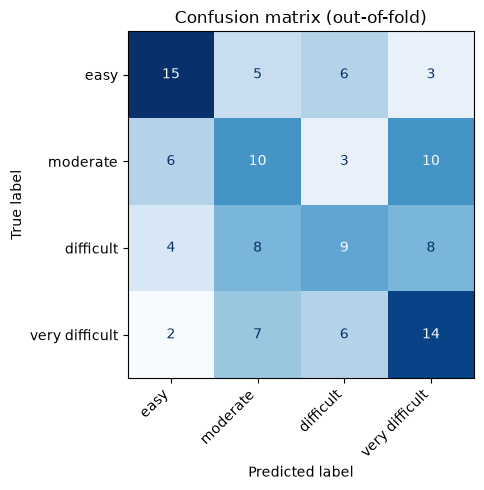

In [4]:
# Out-of-fold predictions for every trail
pred = cross_val_predict(rf, X, y, cv=cv)

exact = accuracy_score(y, pred)
within_one = (np.abs(pred - y) <= 1).mean()   # off by at most one difficulty level
print(f'Exact accuracy        : {exact:.1%}')
print(f'Within-one-level      : {within_one:.1%}')

fig, ax = plt.subplots(figsize=(5.5,5))
ConfusionMatrixDisplay.from_predictions(y, pred, display_labels=ORDER,
                                        cmap='Blues', ax=ax, colorbar=False)
plt.xticks(rotation=45, ha='right'); plt.title('Confusion matrix (out-of-fold)')
plt.tight_layout(); plt.show()

**The confusion matrix:** strong diagonal-ish band shows most predictions are right or land one level away. Almost no "easy" trail is called "very difficult" or vice-versa. As such, the model rarely makes a *big* mistake. That's why **within-one-level accuracy (~72%)** is the fairer headline for a subjective 4-level scale.

As a sanity check, collapsing the fuzzy top boundary into 3 levels (easy / moderate / hard) lifts accuracy to ~56%, and a simple easier-vs-harder split reaches ~66%. The signal is real; the exact 4-way cut is just inherently fuzzy.

## 4. Which features matter? (SHAP)

SHAP measures how much each feature pushes a prediction toward or away from each difficulty level. I trained Random Forest on all the data.

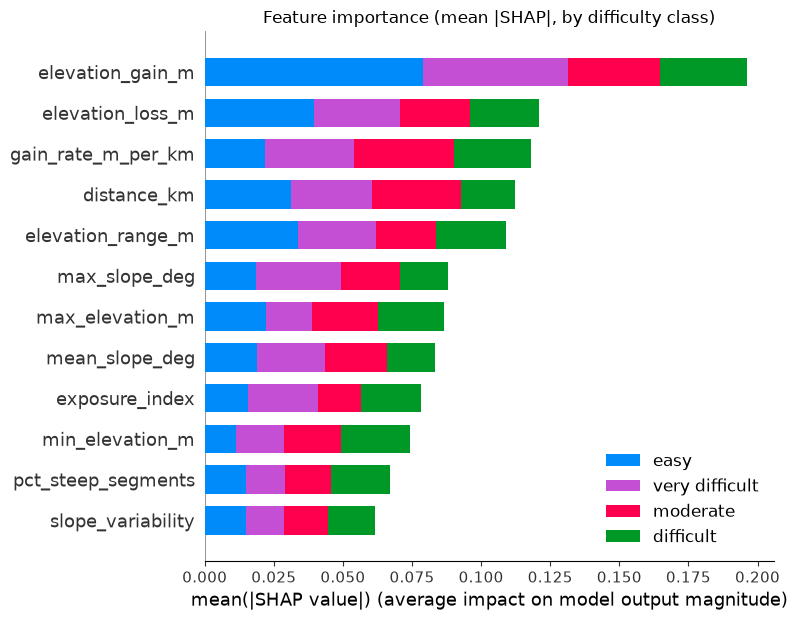

In [5]:
rf.fit(X, y)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X, plot_type='bar', class_names=ORDER, show=False)
plt.title('Feature importance (mean |SHAP|, by difficulty class)')
plt.tight_layout(); plt.show()

**What SHAP reveals:** `elevation_gain_m` is the single biggest driver, followed by `elevation_loss_m`, `gain_rate_m_per_km`, and `distance_km`. In other words, **total climbing and total distance**, the endurance factors, **dominate**, with steepness/slope features playing a secondary role.

This is the data-driven confirmation of the story I spotted back in notebook 03: difficulty here is driven more by *how much climbing and distance* a trail demands than by raw steepness.

## 5. Save the model

I save the trained model and the class order so the web app can load them later and make predictions without retraining.

In [6]:
import joblib, os, json
os.makedirs('../models', exist_ok=True)
joblib.dump(rf, '../models/rf_model.pkl')
json.dump({'features': FEATURES, 'order': ORDER}, open('../models/model_meta.json','w'), indent=2)
print('Saved model -> models/rf_model.pkl and models/model_meta.json')

Saved model -> models/rf_model.pkl and models/model_meta.json


## 6. Recap & what's next

- Trained Random Forest vs XGBoost; RF wins on this small dataset (~41% exact, ~72% within one level).
- The confusion matrix shows errors are near-misses, not wild mistakes.
- SHAP confirms climbing + distance (endurance) drive difficulty most.
- Saved the model for the app.

On subjective, single-source labels with 116 trails, the model reaches 72% within-one-level accuracy and, more importantly, SHAP shows it relies on sensible terrain features, led by total climb and distance.

**Next:** wrap this model in a web app (Streamlit + FastAPI) so anyone can upload a GPX and get a prediction + feature breakdown. Possible model improvements later: more trails, treating difficulty as ordinal regression, or averaging ratings from multiple sources to reduce label noise.